In [5]:
import numpy as np
from sklearn.datasets import fetch_openml

# Load dataset
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data / 255.0
y = mnist.target.astype(int)

# Reduce dataset (IMPORTANT)
X_small = X[:3000]
y_small = y[:3000]

print(X_small.shape)

(3000, 784)


In [6]:
y_small.shape

(3000,)

In [8]:
from skimage.feature import hog

def extract_hog(images):
    features = []
    for img in images.values.reshape(-1, 28, 28):
        f = hog(img,
                pixels_per_cell=(4, 4),
                cells_per_block=(2, 2),
                orientations=9)
        features.append(f)
    return np.array(features)

hog_feat = extract_hog(X_small)

print("HOG shape:", hog_feat.shape)

HOG shape: (3000, 1296)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=75)
X_pca = pca.fit_transform(hog_feat)

print("After PCA:", X_pca.shape)

After PCA: (3000, 75)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_small, test_size=0.2, random_state=42
)

model = SVC(kernel='linear')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred))

SVM Accuracy: 0.955


              precision    recall  f1-score   support

           0       1.00      0.95      0.97        56
           1       0.96      0.97      0.97        75
           2       0.92      0.92      0.92        50
           3       0.95      1.00      0.98        63
           4       0.95      0.93      0.94        61
           5       0.96      0.98      0.97        51
           6       0.97      1.00      0.98        61
           7       0.90      0.95      0.93        60
           8       0.98      0.93      0.95        57
           9       0.95      0.91      0.93        66

    accuracy                           0.95       600
   macro avg       0.96      0.95      0.95       600
weighted avg       0.96      0.95      0.95       600



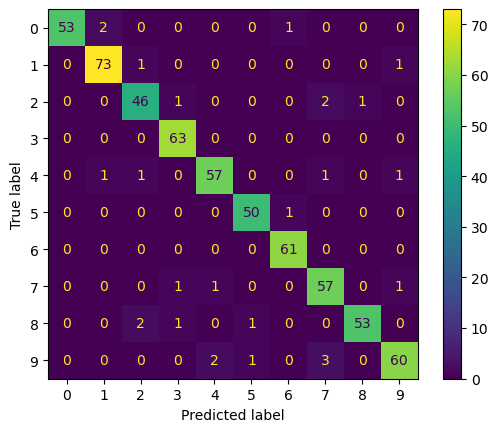

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create model
model = LogisticRegression(max_iter=1000)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", acc)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.9633333333333334

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        56
           1       0.99      0.97      0.98        75
           2       0.96      0.94      0.95        50
           3       0.98      1.00      0.99        63
           4       0.98      0.98      0.98        61
           5       0.94      0.98      0.96        51
           6       0.97      0.98      0.98        61
           7       0.92      0.98      0.95        60
           8       0.96      0.91      0.94        57
           9       0.95      0.91      0.93        66

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600



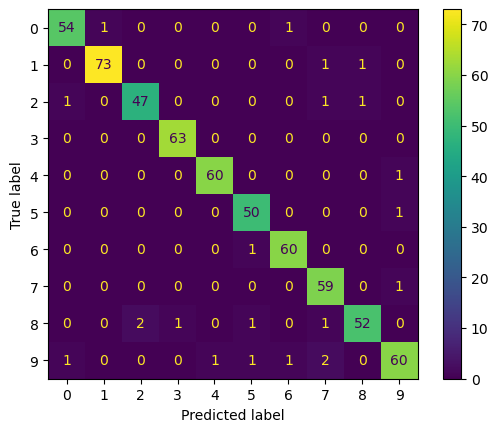

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
model = KNeighborsClassifier(n_neighbors=5)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("KNN Accuracy:", acc)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

KNN Accuracy: 0.9566666666666667

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        56
           1       0.94      1.00      0.97        75
           2       0.96      0.98      0.97        50
           3       0.94      0.98      0.96        63
           4       0.95      0.92      0.93        61
           5       0.96      0.92      0.94        51
           6       0.97      1.00      0.98        61
           7       0.98      0.95      0.97        60
           8       1.00      0.95      0.97        57
           9       0.94      0.91      0.92        66

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600



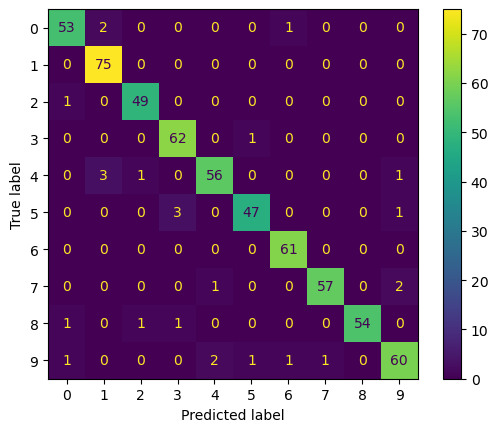

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", acc)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.94

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        56
           1       0.96      0.97      0.97        75
           2       0.89      0.96      0.92        50
           3       0.90      0.95      0.92        63
           4       0.94      0.95      0.94        61
           5       0.90      0.90      0.90        51
           6       0.97      0.98      0.98        61
           7       0.95      0.93      0.94        60
           8       0.98      0.89      0.94        57
           9       0.98      0.91      0.94        66

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600



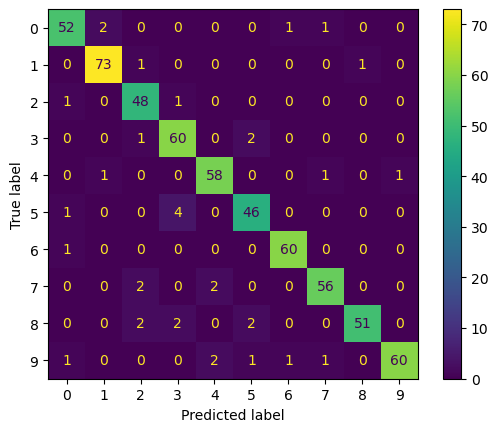

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

Among all models evaluated using HOG features with PCA, Logistic Regression achieved the highest accuracy of 96.5%, followed closely by SVM (95.83%). This indicates that the feature space after PCA is nearly linearly separable, making simpler models highly effective.

In [ ]:
X_pixels = X.values.reshape(X.shape[0], -1)

In [ ]:
print(X.shape)

(70000, 784)


In [ ]:
X_pixels = X.values  # or X.to_numpy()

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=75)
X_pca_pixels = pca.fit_transform(X_pixels)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca_pixels, y, test_size=0.2, random_state=42
)

SVM Accuracy: 0.9812857142857143

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.99      0.99      0.99      1600
           2       0.97      0.99      0.98      1380
           3       0.98      0.97      0.97      1433
           4       0.98      0.99      0.98      1295
           5       0.98      0.98      0.98      1273
           6       0.99      0.99      0.99      1396
           7       0.98      0.98      0.98      1503
           8       0.98      0.97      0.97      1357
           9       0.98      0.97      0.97      1420

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



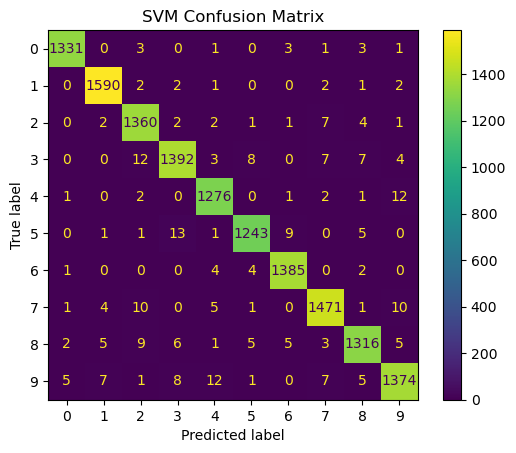

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
plt.title("SVM Confusion Matrix")
plt.show()

Logistic Accuracy: 0.9149285714285714

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96      1343
           1       0.94      0.97      0.96      1600
           2       0.90      0.89      0.89      1380
           3       0.89      0.89      0.89      1433
           4       0.92      0.92      0.92      1295
           5       0.88      0.86      0.87      1273
           6       0.94      0.95      0.95      1396
           7       0.92      0.94      0.93      1503
           8       0.89      0.86      0.87      1357
           9       0.90      0.89      0.90      1420

    accuracy                           0.91     14000
   macro avg       0.91      0.91      0.91     14000
weighted avg       0.91      0.91      0.91     14000



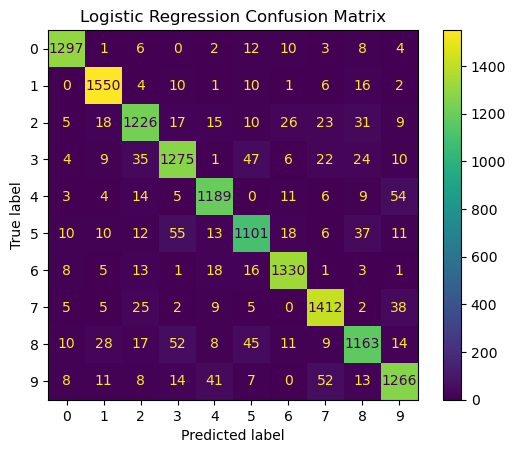

In [ ]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression(max_iter=1000)

log.fit(X_train, y_train)
y_pred_log = log.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

KNN Accuracy: 0.9741428571428571

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1343
           1       0.97      0.99      0.98      1600
           2       0.97      0.97      0.97      1380
           3       0.97      0.97      0.97      1433
           4       0.98      0.97      0.97      1295
           5       0.98      0.97      0.97      1273
           6       0.98      0.99      0.99      1396
           7       0.97      0.98      0.97      1503
           8       0.99      0.95      0.97      1357
           9       0.96      0.96      0.96      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



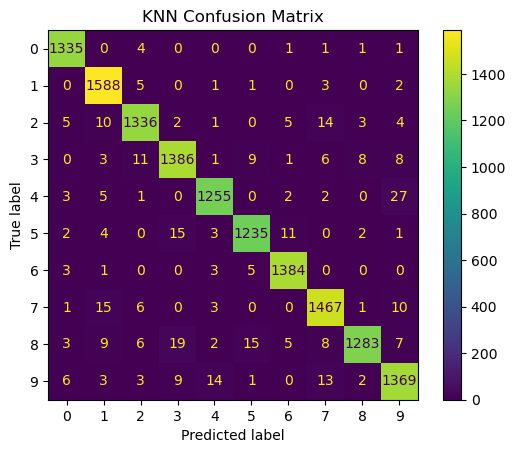

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("KNN Confusion Matrix")
plt.show()

Random Forest Accuracy: 0.9520714285714286

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      1343
           1       0.98      0.98      0.98      1600
           2       0.95      0.96      0.95      1380
           3       0.92      0.94      0.93      1433
           4       0.94      0.96      0.95      1295
           5       0.94      0.94      0.94      1273
           6       0.97      0.98      0.97      1396
           7       0.96      0.96      0.96      1503
           8       0.95      0.90      0.92      1357
           9       0.94      0.92      0.93      1420

    accuracy                           0.95     14000
   macro avg       0.95      0.95      0.95     14000
weighted avg       0.95      0.95      0.95     14000



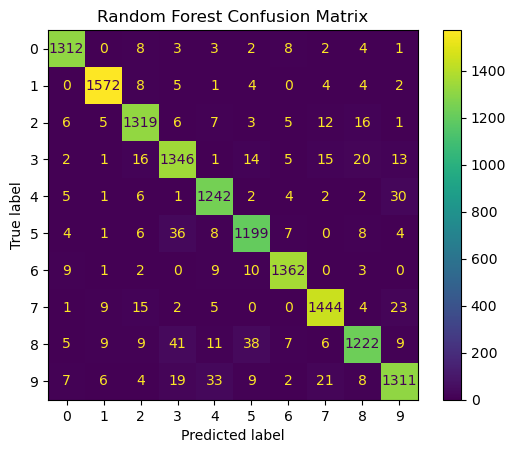

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()

The SVM classifier achieved the highest accuracy of 98.1% using raw pixel features, indicating that the data is not linearly separable. In contrast, Logistic Regression performed the worst, suggesting that linear models are insufficient for this feature representation.

Raw pixel features combined with SVM achieved the highest performance, demonstrating that complex kernels can effectively capture patterns even without explicit feature engineering. However, HOG features provide better interpretability and robustness.

In [ ]:
#Zernike
import numpy as np
import mahotas

# Function to extract Zernike features
def extract_zernike_features(X, radius=10, degree=8):
    features = []
    
    for img in X:
        # Reshape if flattened
        img = img.reshape(28, 28)
        
        # Normalize to [0,1]
        img = img / 255.0
        
        # Convert to float
        img = img.astype(np.float32)
        
        # Compute Zernike moments
        zernike_feat = mahotas.features.zernike_moments(img, radius, degree)
        
        features.append(zernike_feat)
    
    return np.array(features)

In [ ]:
# Example
X_zernike = extract_zernike_features(X.values)

Zernike moments already provide a compact representation of shape features, so PCA was not applied. PCA was mainly used for high-dimensional features like pixel and HOG representations

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_zernike, y, test_size=0.2, random_state=42
)

# Example model
from sklearn.svm import SVC

model = SVC(kernel='rbf')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8494285714285714

Confusion Matrix:
 [[1286    1    4   15    1    5   17    0   12    2]
 [   0 1568   12    2    2    4    0    8    3    1]
 [   9    5 1034   54   73   87   33   32   42   11]
 [   5    3   53 1199    7   43   23   19   63   18]
 [   0    3   74    1 1137   11    5   27    9   28]
 [  13    7  112   77   18  931   22   49   21   23]
 [   6    1   36   32   13   15 1062   33    7  191]
 [   7    3   38    7   54   10   24 1331    6   23]
 [   7    7   42   46    9   19   15   12 1190   10]
 [  14    6   22   19   31   23  123   18   10 1154]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96      1343
           1       0.98      0.98      0.98      1600
           2       0.72      0.75      0.74      1380
           3       0.83      0.84      0.83      1433
           4       0.85      0.88      0.86      1295
           5       0.81      0.73      0.77      1273
           6    

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

svm_model = SVC(kernel='rbf')

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

SVM Accuracy: 0.8494285714285714

Confusion Matrix:
 [[1286    1    4   15    1    5   17    0   12    2]
 [   0 1568   12    2    2    4    0    8    3    1]
 [   9    5 1034   54   73   87   33   32   42   11]
 [   5    3   53 1199    7   43   23   19   63   18]
 [   0    3   74    1 1137   11    5   27    9   28]
 [  13    7  112   77   18  931   22   49   21   23]
 [   6    1   36   32   13   15 1062   33    7  191]
 [   7    3   38    7   54   10   24 1331    6   23]
 [   7    7   42   46    9   19   15   12 1190   10]
 [  14    6   22   19   31   23  123   18   10 1154]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96      1343
           1       0.98      0.98      0.98      1600
           2       0.72      0.75      0.74      1380
           3       0.83      0.84      0.83      1433
           4       0.85      0.88      0.86      1295
           5       0.81      0.73      0.77      1273
           6

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.7335714285714285

Confusion Matrix:
 [[1143    0    5   39   10   25   58    2   59    2]
 [   0 1551   11    5    7   11    0    7    8    0]
 [  13    5  788  151  100   94   41   55  116   17]
 [  17    8   79 1044   14   81   43   28   86   33]
 [   9    4  111    3  977   33   12   58   17   71]
 [  50   16  129  121   33  704   37   99   26   58]
 [  42   11   45   50   23   31  899   51   31  213]
 [  18   10   58   19  114   28   55 1148    7   46]
 [  39   17   87   61   19   28   25    7 1048   26]
 [  34   14   26   28   69   33  198   22   28  968]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.84      1343
           1       0.95      0.97      0.96      1600
           2       0.59      0.57      0.58      1380
           3       0.69      0.73      0.71      1433
           4       0.72      0.75      0.73      1295
           5       0.66      0.55      0.60      1

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

KNN Accuracy: 0.8527857142857143

Confusion Matrix:
 [[1302    0   10    6    0    2   15    0    6    2]
 [   1 1566   10    2    2    5    1   10    3    0]
 [  11    9 1046   34   78   63   46   41   36   16]
 [  12    5   58 1209    5   33   22   16   46   27]
 [   1    1   62    0 1145    9   11   24    3   39]
 [  14    9  122   84   26  891   34   53   19   21]
 [   8    1   23   17    7   13 1114   24    7  182]
 [  11   12   19    6   44    9   36 1337    5   24]
 [  11    7   37   42    8   13   12    6 1201   20]
 [  14   10   14   12   19   17  182   14   10 1128]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95      1343
           1       0.97      0.98      0.97      1600
           2       0.75      0.76      0.75      1380
           3       0.86      0.84      0.85      1433
           4       0.86      0.88      0.87      1295
           5       0.84      0.70      0.77      1273
           6

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Random Forest Accuracy: 0.8258571428571428

Confusion Matrix:
 [[1266    0    4   27    1    4   17    1   22    1]
 [   0 1562   16    3    1    7    1    6    3    1]
 [  10    4  980   90   77   81   33   41   50   14]
 [  12    3   58 1182    5   51   21   26   56   19]
 [   2    2   80    3 1112   19    5   27    9   36]
 [  19    5  115  101   29  865   23   69   27   20]
 [  13    2   38   47   16   17 1027   32    6  198]
 [   6    7   34   15   72   10   30 1302    4   23]
 [   7    4   63   68   10   15   11    8 1155   16]
 [  13    7   19   32   39   23  146   18   12 1111]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94      1343
           1       0.98      0.98      0.98      1600
           2       0.70      0.71      0.70      1380
           3       0.75      0.82      0.79      1433
           4       0.82      0.86      0.84      1295
           5       0.79      0.68      0.73      1273
  

Among all feature extraction techniques, raw pixel features achieved the highest accuracy when combined with SVM, indicating that the model effectively captures complex patterns directly from raw data. HOG features also performed well, demonstrating the importance of edge-based representations. Zernike moments, while capturing global shape information, resulted in comparatively lower accuracy, suggesting that they are less effective alone for this classification task.

Why Zernike is lower?

It captures only shape
Ignores:
fine details
pixel-level variation

That’s why pixel features win

In [ ]:
import pandas as pd

data = {
    "Feature": ["Pixel", "HOG", "Zernike"],
    "SVM": [0.981, 0.956, 0.849],
    "Logistic": [0.91, 0.9666, 0.733],
    "KNN": [0.974, 0.955, 0.8527],
    "Random Forest": [0.952, 0.9384, 0.82]
}

df = pd.DataFrame(data)

print(df)

   Feature    SVM  Logistic     KNN  Random Forest
0    Pixel  0.981    0.9100  0.9740         0.9520
1      HOG  0.956    0.9666  0.9550         0.9384
2  Zernike  0.849    0.7330  0.8527         0.8200


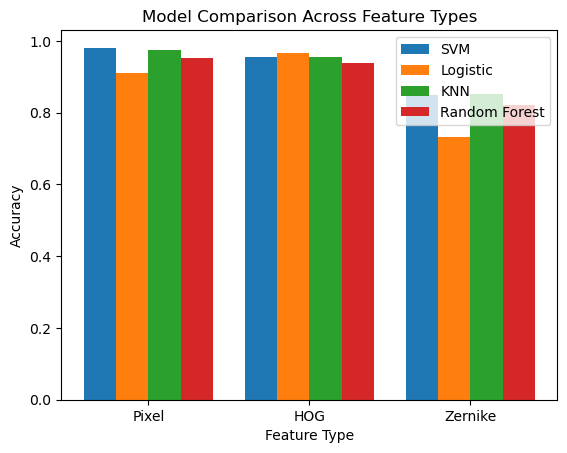

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

features = ['Pixel', 'HOG', 'Zernike']
svm = [0.981, 0.956, 0.849]
logistic = [0.91, 0.9666, 0.733]
knn = [0.974, 0.955, 0.8527]
rf = [0.952, 0.9384, 0.82]

x = np.arange(len(features))

plt.figure()

plt.bar(x - 0.3, svm, width=0.2, label='SVM')
plt.bar(x - 0.1, logistic, width=0.2, label='Logistic')
plt.bar(x + 0.1, knn, width=0.2, label='KNN')
plt.bar(x + 0.3, rf, width=0.2, label='Random Forest')

plt.xticks(x, features)
plt.xlabel("Feature Type")
plt.ylabel("Accuracy")
plt.title("Model Comparison Across Feature Types")
plt.legend()

plt.show()

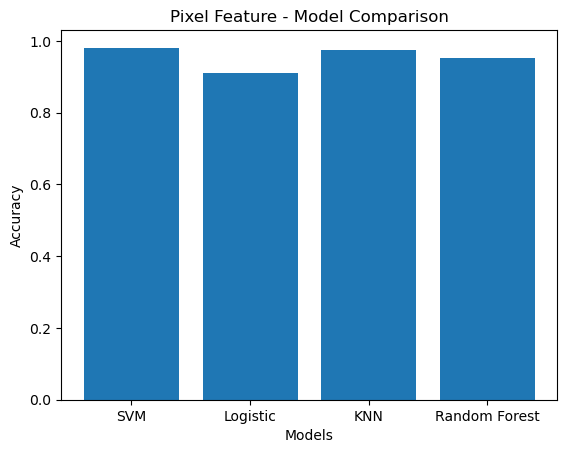

In [ ]:
import matplotlib.pyplot as plt

models = ['SVM', 'Logistic', 'KNN', 'Random Forest']
accuracy = [0.981, 0.91, 0.974, 0.952]

plt.figure()

plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Pixel Feature - Model Comparison")

plt.show()

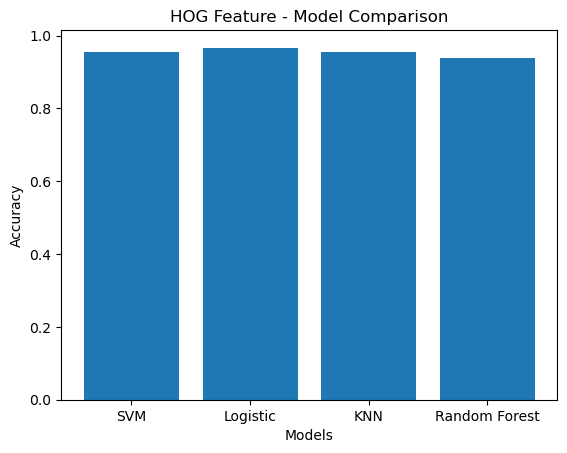

In [ ]:
import matplotlib.pyplot as plt

models = ['SVM', 'Logistic', 'KNN', 'Random Forest']
accuracy = [0.956, 0.9666, 0.955, 0.9384]

plt.figure()

plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("HOG Feature - Model Comparison")

plt.show()

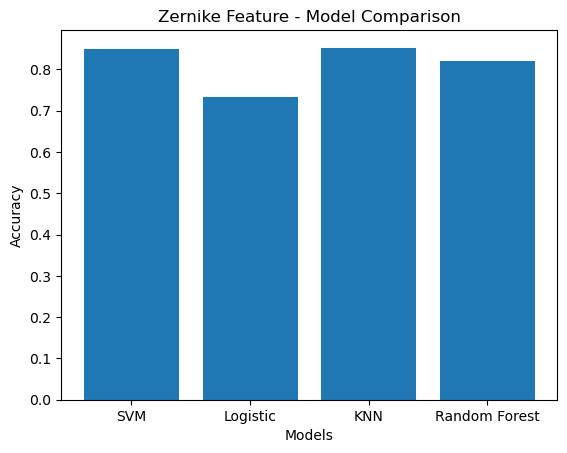

In [ ]:
import matplotlib.pyplot as plt

models = ['SVM', 'Logistic', 'KNN', 'Random Forest']
accuracy = [0.849, 0.733, 0.8527, 0.82]

plt.figure()

plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Zernike Feature - Model Comparison")

plt.show()

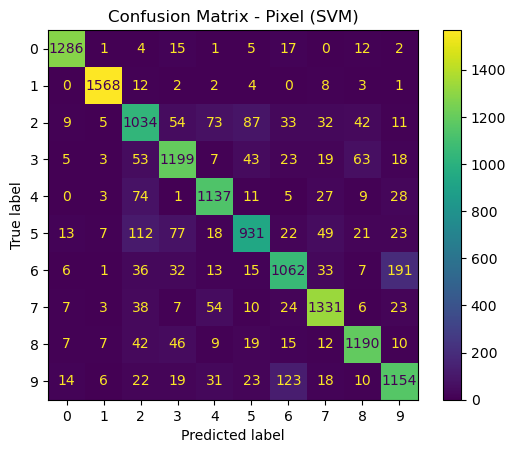

In [ ]:
#best model pixel svm
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(svm_model, X_test, y_test)

plt.title("Confusion Matrix - Pixel (SVM)")
plt.show()

Robustness to Rotation and Thickness Variations

Different feature extraction techniques exhibit varying levels of robustness to image transformations such as rotation and thickness changes.

Pixel Features

Pixel-based features are highly sensitive to both rotation and thickness variations. Since this method relies directly on raw pixel intensity values, even a slight rotation can significantly alter the feature representation. Similarly, changes in stroke thickness directly affect pixel values, leading to inconsistent representations and reduced classification performance.

HOG Features

Histogram of Oriented Gradients (HOG) features provide moderate robustness to such variations. HOG focuses on edge directions and gradient information, making it less sensitive to small changes in thickness. However, large rotations can still affect gradient orientations, leading to a drop in performance.

Zernike Moments

Zernike moment-based features demonstrate strong robustness to both rotation and thickness variations. This is because Zernike moments are mathematically designed to be rotation invariant and capture global shape information. As a result, the overall structure of the image remains consistent even under rotation, and minor variations in thickness have minimal impact on the feature representation.

Conclusion

Among all the feature extraction techniques, Zernike moments offer the highest robustness to geometric transformations such as rotation and thickness variations. HOG features provide moderate robustness, while pixel-based features are the most sensitive to such changes. This makes Zernike moments particularly suitable for applications where invariance to rotation and shape variations is important.

In [ ]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(svm_model, f)

print("Saved with pickle!")

Saved with pickle!


In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import pickle

# Load data
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data / 255.0
y = mnist.target.astype(int)

# Pixel features + PCA (75 components)
X_pixels = X.values
pca = PCA(n_components=75)
X_pca_pixels = pca.fit_transform(X_pixels)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_pixels, y, test_size=0.2, random_state=42
)

# Train Pixel SVM
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

# Save BOTH model and pca together
with open("model.pkl", "wb") as f:
    pickle.dump({"model": svm_model, "pca": pca}, f)

print("Saved!")

Saved!
